**Goal:** close Unit VII by *un-mixing* columns instead of compressing them. You will mix three signals
into three scrambled recordings, then watch **ICA** recover the originals almost perfectly (best
correlation 0.997) where **PCA** cannot (0.6-0.8) -- the **blind source separation** / cocktail-party
problem. Then you will meet **Factor Analysis**, PCA's probabilistic cousin, and see it beat PCA exactly
when the features carry *unequal* noise. Pairs with the concept note
[Factor Analysis & ICA](l27_concept_factor_analysis_ica.qmd).

> **Previously:** L26 -- Principal Component Analysis  |  **Next:** L28 -- Reinforcement Learning: The Paradigm

> This page is the read-only view. To run the lab, open the notebook
> (`l27_lab_factor_analysis_ica.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

Three people speak at once in a room with three microphones. Each microphone records a *different blend*
of the three voices -- no recording is clean. Given only the three mixtures and **no** prior knowledge of
the sources, can we recover the original voices? We simulate it with three easy-to-see signals -- a
**sine**, a **square** wave, and a **sawtooth** -- standardized and then linearly **mixed** by a fixed
matrix. PCA, which only finds uncorrelated max-variance directions, will fail; ICA, which insists the
recovered signals be statistically **independent** (and exploits their **non-Gaussian** shape), will
succeed.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the second imports,
builds the three sources, and mixes them.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, scipy, numpy and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn scipy
# local, in a terminal (not in the notebook):  uv add scikit-learn scipy numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + BUILD THE MIXED SIGNALS (safe to re-run without re-installing)
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import PCA, FastICA, FactorAnalysis
from sklearn.model_selection import cross_val_score

np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)
s1 = np.sin(2 * time)                       # sine wave
s2 = np.sign(np.sin(3 * time))              # square wave
s3 = signal.sawtooth(2 * np.pi * time)      # sawtooth wave
S = np.c_[s1, s2, s3]
S += 0.2 * np.random.normal(size=S.shape)   # add a little noise
S /= S.std(axis=0)                          # standardize each source
A = np.array([[1.0, 1.0, 1.0],
              [0.5, 2.0, 1.0],
              [1.5, 1.0, 2.0]])             # mixing matrix
X = S @ A.T                                 # the observed mixtures (what we actually record)
print("sources S:", S.shape, "| observations X:", X.shape)

sources S: (2000, 3) | observations X: (2000, 3)


~~~text
sources S: (2000, 3) | observations X: (2000, 3)
~~~

## Step 1: Mix the Signals

`S` holds the three clean sources; `X = S @ A.T` is what the microphones hear -- each column of `X` is a
different blend of all three voices. Plot the sources on top and the mixtures below: the mixtures look
nothing like the originals.

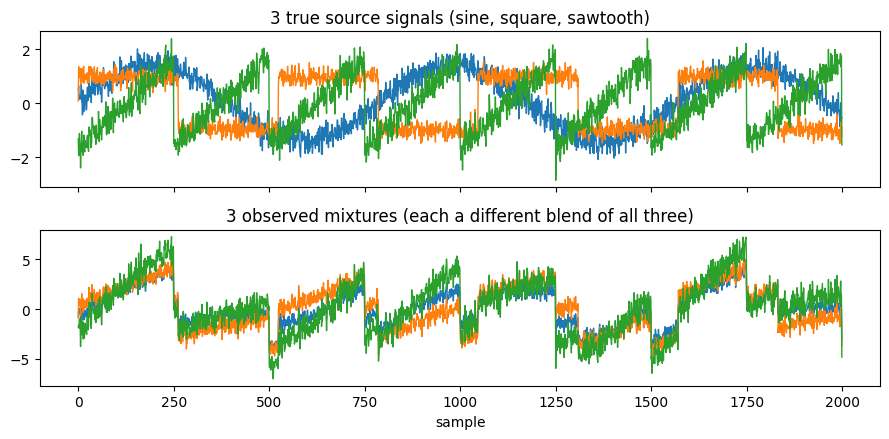

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
for col in S.T:
    axes[0].plot(col, lw=1)
axes[0].set_title("3 true source signals (sine, square, sawtooth)")
for col in X.T:
    axes[1].plot(col, lw=1)
axes[1].set_title("3 observed mixtures (each a different blend of all three)")
axes[1].set_xlabel("sample")
plt.tight_layout(); plt.show()

The recordings are tangled. Our job is to invert the mixing using nothing but the mixtures themselves.

## Step 2: ICA Recovers the Sources -- PCA Does Not

Fit both methods asking for 3 components. **ICA** (`FastICA`) looks for three signals that are
statistically **independent**; **PCA** looks for three uncorrelated directions of maximum variance. To
score them, measure the best absolute correlation between each true source and any recovered component
(the recovered signals come out in any order, sign, and scale, so we match by correlation):

In [4]:
ica = FastICA(n_components=3, whiten="arbitrary-variance", random_state=0)
S_ica = ica.fit_transform(X)        # ICA's recovered sources
pca = PCA(n_components=3)
S_pca = pca.fit_transform(X)        # PCA's components, for comparison

names = ["sine    ", "square  ", "sawtooth"]
def best_corr(true_col, est):
    return np.abs([np.corrcoef(true_col, est[:, j])[0, 1] for j in range(est.shape[1])]).max()

print("recovery -- best |corr| of each true source to any recovered component:")
print("  source      ICA    PCA")
for i in range(3):
    print(f"  {names[i]}  {best_corr(S[:, i], S_ica):.3f}  {best_corr(S[:, i], S_pca):.3f}")

recovery -- best |corr| of each true source to any recovered component:
  source      ICA    PCA
  sine      0.997  0.755
  square    1.000  0.787
  sawtooth  0.997  0.671


~~~text
recovery -- best |corr| of each true source to any recovered component:
  source      ICA    PCA
  sine      0.997  0.755
  square    1.000  0.787
  sawtooth  0.997  0.671
~~~

ICA matches every source at **0.997 or better** -- it un-mixed the voices. PCA tops out around 0.6-0.8:
its orthogonal max-variance axes are still *blends*, not the separate sources. Plot all four sets and the
difference is obvious by eye:

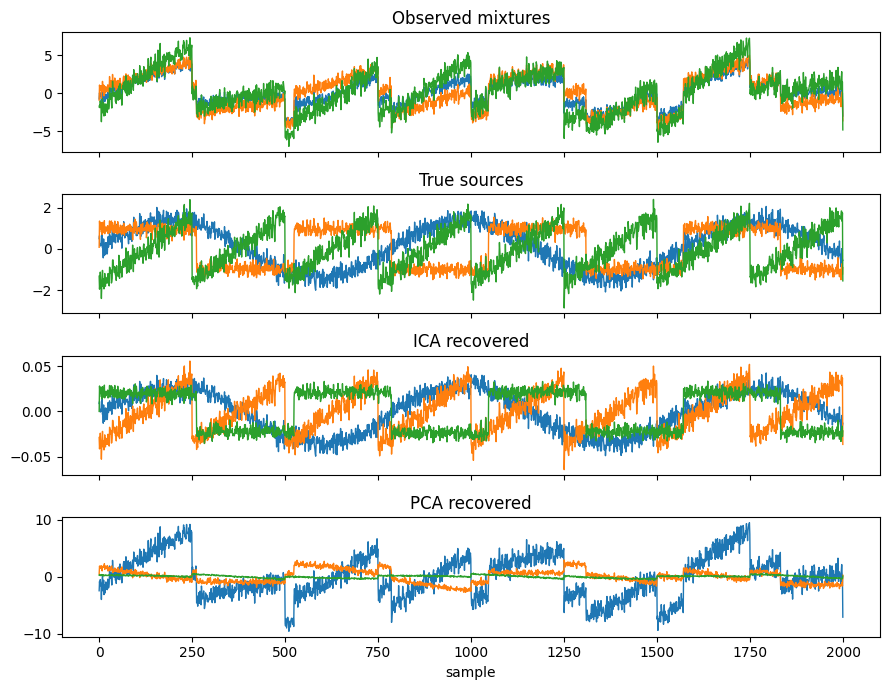

In [5]:
models = [X, S, S_ica, S_pca]
titles = ["Observed mixtures", "True sources", "ICA recovered", "PCA recovered"]
fig, axes = plt.subplots(4, 1, figsize=(9, 7), sharex=True)
for ax, data, title in zip(axes, models, titles):
    for col in data.T:
        ax.plot(col, lw=1)
    ax.set_title(title)
axes[-1].set_xlabel("sample")
plt.tight_layout(); plt.show()

The ICA panel reproduces the clean sine, square, and sawtooth (reordered and possibly flipped); the PCA
panel is still a set of mixtures. PCA **decorrelates**; ICA **separates**. The difference is that ICA
demands full statistical **independence**, which it can find because the sources are **non-Gaussian** --
a Gaussian source set would be unrecoverable.

## Step 3: Factor Analysis vs PCA -- When Noise Is Unequal

**Factor Analysis** is PCA's probabilistic cousin: it models the data as a few latent Gaussian
**factors** linearly mixed, plus **per-feature** noise it estimates separately for each feature. PCA, in
effect, assumes that noise is the *same* in every feature. So FA should win when the features are noisy
by *different* amounts (heteroscedastic), and merely tie PCA when the noise is equal. Build a 6-feature
dataset from 2 hidden factors with deliberately unequal noise, and check:

In [6]:
rng = np.random.default_rng(42)
n, k, p = 1000, 2, 6
Z = rng.standard_normal((n, k))          # 2 latent factors per sample
W = rng.standard_normal((k, p))          # loadings: 2 factors -> 6 features
core = Z @ W                             # the shared low-rank signal
noise_std = np.array([0.1, 0.1, 0.5, 0.5, 2.0, 2.0])   # per-feature noise (heteroscedastic)
Xh = core + rng.standard_normal((n, p)) * noise_std    # 6 features, unequal noise
Xi = core + rng.standard_normal((n, p)) * 0.8          # same signal, one equal noise level

fa = FactorAnalysis(n_components=2, random_state=0).fit(Xh)
print("FA noise_variance_ :", fa.noise_variance_.round(3))
print("injected noise var :", (noise_std**2).round(3))

print("\nCV mean log-likelihood (5-fold), higher is better:")
for label, Xd in [("heteroscedastic", Xh), ("homoscedastic  ", Xi)]:
    fa_ll = cross_val_score(FactorAnalysis(n_components=2, random_state=0), Xd, cv=5).mean()
    pca_ll = cross_val_score(PCA(n_components=2), Xd, cv=5).mean()
    tag = "FA wins" if fa_ll - pca_ll > 0.1 else "tie"
    print(f"  {label} noise:  FA {fa_ll:6.2f}   PCA {pca_ll:6.2f}   -> {tag}")

FA noise_variance_ : [0.021 0.019 0.237 0.256 3.477 4.32 ]
injected noise var : [0.01 0.01 0.25 0.25 4.   4.  ]

CV mean log-likelihood (5-fold), higher is better:
  heteroscedastic noise:  FA  -7.85   PCA  -8.94   -> FA wins


  homoscedastic   noise:  FA  -9.02   PCA  -9.03   -> tie


~~~text
FA noise_variance_ : [0.021 0.019 0.237 0.256 3.477 4.32 ]
injected noise var : [0.01 0.01 0.25 0.25 4.   4.  ]

CV mean log-likelihood (5-fold), higher is better:
  heteroscedastic noise:  FA  -7.85   PCA  -8.94   -> FA wins
  homoscedastic   noise:  FA  -9.02   PCA  -9.03   -> tie
~~~

FA's `noise_variance_` recovers the injected pattern -- tiny for the first two features, medium for the
middle two, large for the last two -- because it has a per-feature noise term to absorb it. On held-out
data FA beats PCA by about 1.1 nats when the noise is **unequal**, and ties it when the noise is
**equal** (PCA is exactly the equal-noise special case). That is the whole point of FA: it pays off
precisely when your features are noisy by different amounts.

## Your Turn

### Exercise 1 -- Uncorrelated is not independent

PCA's components are uncorrelated by construction. So are ICA's (it whitens first). Yet only ICA
recovered the true sources. Confirm both sets are decorrelated -- then remember from Step 2 that only one
of them actually separated the voices.

In [7]:
# TODO: largest |correlation| between any two DISTINCT recovered components, for each method.
#   def max_offdiag(M):
#       C = np.abs(np.corrcoef(M.T)); np.fill_diagonal(C, 0.0); return C.max()
#   print(f"max |off-diagonal corr|:  ICA {max_offdiag(S_ica):.3f}  PCA {max_offdiag(S_pca):.3f}")

<details><summary>Expected Output</summary>

~~~text
max |off-diagonal corr|:  ICA 0.000  PCA 0.000
~~~

Both methods produce components with essentially **zero** pairwise correlation -- they are equally
"uncorrelated". But Step 2 showed only ICA's components match the true sources (0.997 vs 0.6-0.8).
**Uncorrelated is weaker than independent:** zero linear correlation only kills *second-order* structure,
while independence (which ICA enforces by maximizing non-Gaussianity) kills *all* statistical dependence.
That extra demand is exactly what lets ICA un-mix the signals where PCA cannot.
</details>

### Exercise 2 -- A taste of a nonlinear method (t-SNE)

PCA, FA, and ICA are all **linear**. The last family in Unit VII bends -- **manifold** methods like
**t-SNE** and **LLE** unfold curved structure for a 2-D picture (their mechanics are beyond this lesson).
Run t-SNE on the digits from L26 and compare the separation to PCA's flat 2-D projection there.

In [8]:
# TODO: t-SNE the digits to 2-D and colour by the true label (visualization only).
#   from sklearn.datasets import load_digits
#   from sklearn.manifold import TSNE
#   Xd, yd = load_digits(return_X_y=True)
#   emb = TSNE(n_components=2, init="pca", learning_rate="auto", random_state=42).fit_transform(Xd)
#   print("t-SNE embedding of the digits:", emb.shape)
#   plt.scatter(emb[:, 0], emb[:, 1], c=yd, s=8, cmap="tab10"); plt.colorbar(label="digit"); plt.show()

<details><summary>Expected Output</summary>

~~~text
t-SNE embedding of the digits: (1797, 2)
~~~

t-SNE pulls the ten digit classes into ten tight, well-separated islands -- far cleaner than the
overlapping blob PCA's first two components gave in L26, because t-SNE is free to bend the space instead
of taking one straight projection. The cost is that it is slower, stochastic, and for *visualization
only* (you cannot `transform` new points or read off variance) -- which is why PCA remains the default
and t-SNE is the special-occasion tool.
</details>

## Summary

- **ICA** solves **blind source separation**: from three scrambled mixtures it recovered the three
  sources at best `|corr|` **0.997+**, while **PCA** stalled at 0.6-0.8. PCA only **decorrelates**; ICA
  **separates**, by demanding statistical **independence** and exploiting the sources' **non-Gaussian**
  shape.
- **Uncorrelated is not independent** (Ex1): both methods gave components with ~0 pairwise correlation,
  but only ICA's matched the true sources. Independence is the stronger condition.
- **Factor Analysis** models latent Gaussian **factors** plus **per-feature** noise; its
  `noise_variance_` recovered the injected unequal noise, and on held-out data it **beat PCA by ~1.1
  nats under heteroscedastic noise** and merely **tied** it under equal noise -- PCA is the equal-noise
  special case.
- The Unit VII toolbox: **PCA** (compress / visualize, linear), **FA** (latent factors + unequal noise),
  **ICA** (separate independent sources); and the **nonlinear** manifold methods **t-SNE / LLE** for
  curved structure (Ex2) -- t-SNE split the digits into ten clean islands where PCA's flat projection
  overlapped.
- Next (L28): the course closes with a different kind of learning entirely -- **Reinforcement Learning**,
  where an agent learns from rewards instead of from a fixed dataset.